  Preparing metadata (setup.py) ... done
🚀 프로세스 시작...


/tmp/ipython-input-3969432640.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


🔥 모델 학습 중...
🔍 결과 예측 중...

💰 내 전략 최종 가치: 1,618,879 원
📈 Buy & Hold 최종 가치: 1,257,241 원


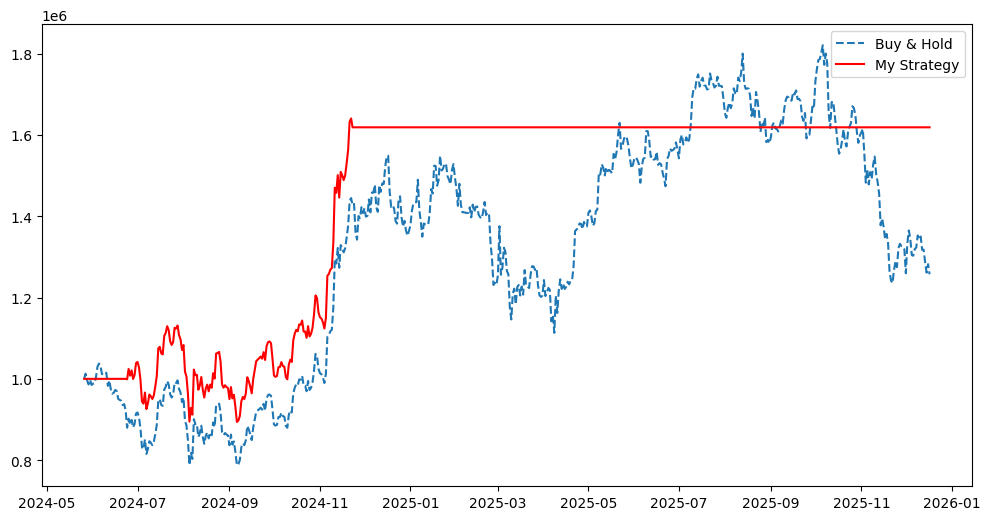

In [1]:
# ==========================================
# [통합 코드] 비트코인 트레이딩 전략 과제
# ==========================================

# 1. 라이브러리 설치 및 준비
!pip install ta yfinance -q
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import ta
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 2. 데이터 다운로드 및 전처리 함수
def load_bitcoin_data(start_date, end_date=None, ticker="BTC-USD"):
    if end_date is None:
        end_date = datetime.now().strftime("%Y-%m-%d")
    df = yf.download(ticker, start=start_date, end=end_date)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def create_features(df):
    df = df.copy()
    df['ma5'] = df['Close'].rolling(window=5).mean()
    df['ma20'] = df['Close'].rolling(window=20).mean()
    bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
    df['bb_high'] = bb.bollinger_hband()
    df['bb_low'] = bb.bollinger_lband()
    df['rsi'] = ta.momentum.rsi(df['Close'], window=14)
    macd = ta.trend.MACD(df['Close'])
    df['macd'] = macd.macd()
    df['obv'] = ta.volume.on_balance_volume(df['Close'], df['Volume'])
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    return df.dropna()

# 3. 모델 정의 (LSTM)
class MyTradingModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, output_size=1):
        super(MyTradingModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.bn = nn.BatchNorm1d(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.bn(out[:, -1, :])
        out = self.fc(out)
        return self.sigmoid(out)

# 4. 전략 함수
def my_advanced_strategy(probs, prices, dates, initial_capital=1000000):
    cash, holdings = initial_capital, 0
    history = []
    BUY_THRESHOLD = 0.55
    SELL_THRESHOLD = 0.45

    for i in range(len(probs)):
        price, prob = prices[i], probs[i]
        if prob >= BUY_THRESHOLD and cash > 0:
            holdings = (cash * 0.999) / price
            cash = 0
        elif prob <= SELL_THRESHOLD and holdings > 0:
            cash = (holdings * price) * 0.999
            holdings = 0
        history.append(cash + holdings * price)
    return history

# --- 실행 파트 ---
print("🚀 프로세스 시작...")
df = load_bitcoin_data("2018-01-01")
df = create_features(df)

scaler = StandardScaler()
features = [c for c in df.columns if c != 'target']
X = scaler.fit_transform(df[features])
y = df['target'].values

X_seq, y_seq = [], []
SEQ_LEN = 30
for i in range(len(X) - SEQ_LEN):
    X_seq.append(X[i:i+SEQ_LEN])
    y_seq.append(y[i+SEQ_LEN])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

split = int(len(X_seq) * 0.8)
X_train = torch.FloatTensor(X_seq[:split])
y_train = torch.FloatTensor(y_seq[:split])
X_test = torch.FloatTensor(X_seq[split:])
y_test = torch.FloatTensor(y_seq[split:])

model = MyTradingModel(input_size=X_train.shape[2])
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCELoss()

print("🔥 모델 학습 중...")
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
model.train()
for epoch in range(100):
    for bx, by in train_loader:
        optimizer.zero_grad()
        pred = model(bx).squeeze()
        loss = criterion(pred, by)
        loss.backward()
        optimizer.step()

print("🔍 결과 예측 중...")
model.eval()
with torch.no_grad():
    probs = model(X_test).numpy().flatten()

test_prices = df['Close'].iloc[split+SEQ_LEN:].values
test_dates = df.index[split+SEQ_LEN:]

my_res = my_advanced_strategy(probs, test_prices, test_dates)
bnh_res = [1000000/test_prices[0] * p for p in test_prices]

print(f"\n💰 내 전략 최종 가치: {my_res[-1]:,.0f} 원")
print(f"📈 Buy & Hold 최종 가치: {bnh_res[-1]:,.0f} 원")

plt.figure(figsize=(12,6))
plt.plot(test_dates, bnh_res, label='Buy & Hold', linestyle='--')
plt.plot(test_dates, my_res, label='My Strategy', color='red')
plt.legend()
plt.show()
